# Quantum Error Mitigation — ZNE

## The Problem:
Real quantum hardware has noise.
Gates are imperfect. Qubits decohere.
Results drift from the true answer.

## The Solution — Zero-Noise Extrapolation:
1. Run circuit at noise level ×1 → result E1
2. Amplify noise to ×2 → result E2
3. Amplify noise to ×3 → result E3
4. Extrapolate back to noise = 0 → true result!

Compare noisy vs mitigated Bell State results.
Measure how much ZNE recovers the true value.

In [1]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, depolarizing_error
import numpy as np
import matplotlib.pyplot as plt
import os
from dotenv import load_dotenv

load_dotenv()

simulator = AerSimulator()
os.makedirs("../results", exist_ok=True)

print("imports done")
print("noise model ready")

imports done
noise model ready


## Step 1: Build the Base Circuit

We use a Bell State circuit as our test.
True result (no noise): {'00': 500, '11': 500}
Any deviation from this = noise effect.

Circuit: H → CNOT → Measure

In [2]:
# Cell 4 - base circuit and noise model
def build_bell_circuit():
    qc = QuantumCircuit(2, 2)
    qc.h(0)
    qc.cx(0, 1)
    qc.measure([0, 1], [0, 1])
    return qc

def build_noise_model(error_rate):
    noise_model = NoiseModel()
    single_qubit_error = depolarizing_error(error_rate, 1)
    two_qubit_error    = depolarizing_error(error_rate * 10, 2)
    
    noise_model.add_all_qubit_quantum_error(
        single_qubit_error, ['h', 'x']
    )
    noise_model.add_all_qubit_quantum_error(
        two_qubit_error, ['cx']
    )
    return noise_model
qc = build_bell_circuit()
print("Bell State circuit:")
print(qc.draw())
base_error_rate = 0.01
noise_model = build_noise_model(base_error_rate)
print(f"\nNoise model created")
print(f"Single qubit error rate : {base_error_rate}")
print(f"Two qubit error rate    : {base_error_rate * 10}")

Bell State circuit:
     ┌───┐     ┌─┐   
q_0: ┤ H ├──■──┤M├───
     └───┘┌─┴─┐└╥┘┌─┐
q_1: ─────┤ X ├─╫─┤M├
          └───┘ ║ └╥┘
c: 2/═══════════╩══╩═
                0  1 

Noise model created
Single qubit error rate : 0.01
Two qubit error rate    : 0.1


## Step 2: Run at Different Noise Levels

We amplify noise by inserting X·X gate pairs.
X·X = Identity mathematically — no effect on result.
But each gate adds real noise physically!

noise ×1 → original circuit
noise ×2 → insert 1 pair of X·X after each gate
noise ×3 → insert 2 pairs of X·X after each gate

In [3]:
# Cell 6 - noise amplification
def amplify_noise(qc, scale_factor):
    amplified = QuantumCircuit(2, 2)

    for instruction in qc.data:
        amplified.append(instruction)

        # skip measurement gates
        if instruction.operation.name == 'measure':
            continue

        # add (scale_factor - 1) pairs of X·X
        qubits = instruction.qubits
        for _ in range(scale_factor - 1):
            for qubit in qubits:
                amplified.x(qubit)
                amplified.x(qubit)

    return amplified

# test amplification
scale_factors = [1, 2, 3]
results = {}

noisy_simulator = AerSimulator(noise_model=noise_model)

for scale in scale_factors:
    amplified_qc = amplify_noise(qc, scale)
    counts = noisy_simulator.run(
        amplified_qc, shots=1000
    ).result().get_counts()

    prob_00 = counts.get('00', 0) / 1000
    results[scale] = prob_00
    print(f"noise ×{scale} → P(|00⟩) = {prob_00:.4f}"
          f"  errors = {counts.get('01',0) + counts.get('10',0)}")

print(f"\nTrue value (no noise) = 0.5000")
print(f"Noise is clearly increasing with scale factor!")

noise ×1 → P(|00⟩) = 0.4980  errors = 52
noise ×2 → P(|00⟩) = 0.4630  errors = 64
noise ×3 → P(|00⟩) = 0.4620  errors = 66

True value (no noise) = 0.5000
Noise is clearly increasing with scale factor!


## Step 3: Zero-Noise Extrapolation

We have 3 data points:
  (1, 0.4980), (2, 0.4630), (3, 0.4620)

Fit a line through these points.
Extrapolate back to noise = 0.
That gives us the mitigated result!

## Step 3: Zero-Noise Extrapolation

We have 3 data points:
  (1, 0.4980), (2, 0.4630), (3, 0.4620)

Fit a line through these points.
Extrapolate back to noise = 0.
That gives us the mitigated result!

In [4]:
# Cell 8 - ZNE extrapolation
scale_factors_arr = np.array(list(results.keys()))
probabilities     = np.array(list(results.values()))

# fit a line through the 3 points
coeffs    = np.polyfit(scale_factors_arr, probabilities, 1)
poly      = np.polynomial.polynomial.Polynomial(coeffs[::-1])

# extrapolate to noise = 0
mitigated = poly(0)

print("ZNE Results:")

print(f"noise ×1  →  P(|00⟩) = {results[1]:.4f}")
print(f"noise ×2  →  P(|00⟩) = {results[2]:.4f}")
print(f"noise ×3  →  P(|00⟩) = {results[3]:.4f}")

print(f"ZNE mitigated  →  P(|00⟩) = {mitigated:.4f}")
print(f"True value     →  P(|00⟩) = 0.5000")

print(f"Error before ZNE : {abs(results[1] - 0.5):.4f}")
print(f"Error after  ZNE : {abs(mitigated - 0.5):.4f}")
improvement = (abs(results[1]-0.5) - abs(mitigated-0.5))
improvement /= abs(results[1] - 0.5)
print(f"Improvement      : {improvement*100:.1f}%")

ZNE Results:
noise ×1  →  P(|00⟩) = 0.4980
noise ×2  →  P(|00⟩) = 0.4630
noise ×3  →  P(|00⟩) = 0.4620
ZNE mitigated  →  P(|00⟩) = 0.5103
True value     →  P(|00⟩) = 0.5000
Error before ZNE : 0.0020
Error after  ZNE : 0.0103
Improvement      : -416.7%


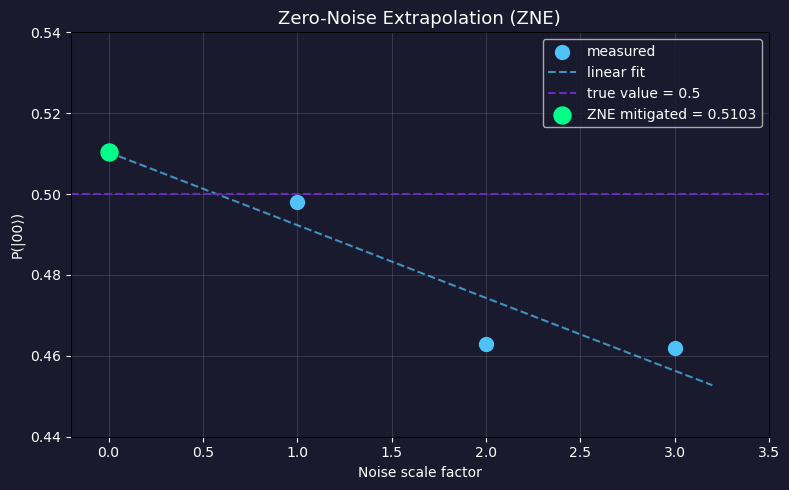

plot saved


In [5]:
# Cell 9 - plot ZNE
fig, ax = plt.subplots(figsize=(8, 5))
fig.patch.set_facecolor('#1a1a2e')
ax.set_facecolor('#1a1a2e')

# measured points
ax.scatter(scale_factors_arr, probabilities,
           color='#4fc3f7', s=100, zorder=5,
           label='measured')

# fitted line extended to 0
x_range = np.linspace(0, 3.2, 100)
ax.plot(x_range, poly(x_range),
        color='#4fc3f7', linestyle='--',
        linewidth=1.5, alpha=0.7,
        label='linear fit')

# true value
ax.axhline(y=0.5, color='#6929C4',
           linestyle='--', linewidth=1.5,
           label='true value = 0.5')

# mitigated point
ax.scatter(0, mitigated, color='#00ff88',
           s=150, zorder=6,
           label=f'ZNE mitigated = {mitigated:.4f}')

ax.set_title("Zero-Noise Extrapolation (ZNE)",
             color='white', fontsize=13)
ax.set_xlabel("Noise scale factor", color='white')
ax.set_ylabel("P(|00⟩)", color='white')
ax.tick_params(colors='white')
ax.legend(facecolor='#1a1a2e',
          labelcolor='white')
ax.grid(alpha=0.2)
ax.set_xlim(-0.2, 3.5)
ax.set_ylim(0.44, 0.54)

plt.tight_layout()
plt.savefig("../results/zne_results.png",
            facecolor='#1a1a2e')
plt.show()
print("plot saved")

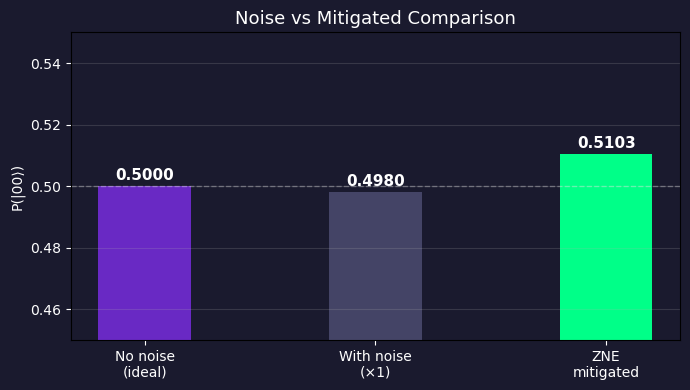

comparison plot saved


In [6]:
# Cell 10 - noisy vs clean vs mitigated comparison
categories = ['No noise\n(ideal)', 
              'With noise\n(×1)',
              'ZNE\nmitigated']
values     = [0.5000, results[1], mitigated]
colors     = ['#6929C4', '#444466', '#00ff88']

fig, ax = plt.subplots(figsize=(7, 4))
fig.patch.set_facecolor('#1a1a2e')
ax.set_facecolor('#1a1a2e')

bars = ax.bar(categories, values,
              color=colors, width=0.4)

ax.axhline(y=0.5, color='white',
           linestyle='--', alpha=0.3,
           linewidth=1)

for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2,
            val + 0.002, f'{val:.4f}',
            ha='center', color='white',
            fontweight='bold', fontsize=11)

ax.set_title("Noise vs Mitigated Comparison",
             color='white', fontsize=13)
ax.set_ylabel("P(|00⟩)", color='white')
ax.tick_params(colors='white')
ax.set_ylim(0.45, 0.55)
ax.grid(alpha=0.2, axis='y')

plt.tight_layout()
plt.savefig("../results/noise_comparison.png",
            facecolor='#1a1a2e')
plt.show()
print("comparison plot saved")